In [21]:
from datetime import datetime
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary
import matplotlib.pyplot as plt

#### Loading the Data

In [22]:
training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)
print(training_data)
print(test_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: ../data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [23]:
import math
def plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test):
    plt.figure(1)
    plt.plot(torch.arange(nepochs), cost_hist, "-", label='train')
    plt.plot(torch.arange(nepochs), cost_hist_test, "r-", label='test')
    mincost = max(max(cost_hist),1.0)
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(0,mincost)
    plt.title("Cross-Entropy Cost")
    plt.legend()
    plt.figure(2)
    plt.plot(torch.arange(nepochs), acc_hist,"-", label='train')
    plt.plot(torch.arange(nepochs), acc_hist_test,"r-", label='test')
    minacc = min(min(acc_hist),0.8)
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(minacc,1)
    plt.legend()
    plt.title("Accuracy")

#### CNN

In [24]:
class CNN2Layer2MLPLayer(torch.nn.Module):
    
    def __init__(self, nhidden=50, noutput=10):
        super(CNN2Layer2MLPLayer, self).__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            torch.nn.ReLU(),
            torch.nn.Flatten(),
            torch.nn.Linear(14*14*32, nhidden),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden, noutput)
        ) 
    
    def forward(self, x):
        z = self.layers(x)
        return z


In [25]:
model = CNN2Layer2MLPLayer(nhidden=50, noutput=10)

In [27]:
summary(model, (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
            Conv2d-3           [-1, 32, 28, 28]           9,248
              ReLU-4           [-1, 32, 28, 28]               0
         MaxPool2d-5           [-1, 32, 14, 14]               0
              ReLU-6           [-1, 32, 14, 14]               0
           Flatten-7                 [-1, 6272]               0
            Linear-8                   [-1, 50]         313,650
              ReLU-9                   [-1, 50]               0
           Linear-10                   [-1, 10]             510
Total params: 323,728
Trainable params: 323,728
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.91
Params size (MB): 1.23
Estimated T

In [28]:
nbatch = 64
nepochs = 10
learning_rate = 0.05

cost_hist = []
cost_hist_test = []
acc_hist = []
acc_hist_test = []

model = CNN2Layer2MLPLayer(nhidden=50, noutput=10)
cost_ce = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10000, shuffle=True)
size = len(training_loader.dataset)
nbatches = len(training_loader)

Xtest, Ytest = next(iter(test_loader))

for epoch in range(nepochs):
    cost, acc = 0.0, 0.0
    for batch, (X, Y) in enumerate(training_loader):
        pred = model(X)
        loss = cost_ce(pred, Y)
        cost += loss.item()
        acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

        # gradient, parameter update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    cost /= nbatches
    acc /= size
    
    with torch.no_grad():
        pred = model(Xtest)
        cost_test = cost_ce(pred, Ytest).item()
        acc_test = (pred.argmax(dim=1) == Ytest).type(torch.float).mean().item()
    print("Epoch %i: %f, %f, %f, %f"%(epoch, cost, acc, cost_test, acc_test))
    cost_hist.append(cost)
    cost_hist_test.append(cost_test)
    acc_hist.append(acc)
    acc_hist_test.append(acc_test)


Epoch 0: 0.398726, 0.872767, 0.108475, 0.966000
Epoch 1: 0.094154, 0.970717, 0.064670, 0.980300
Epoch 2: 0.062001, 0.981183, 0.055629, 0.982300
Epoch 3: 0.046524, 0.985533, 0.043944, 0.984500
Epoch 4: 0.037504, 0.988500, 0.044627, 0.985500


KeyboardInterrupt: 

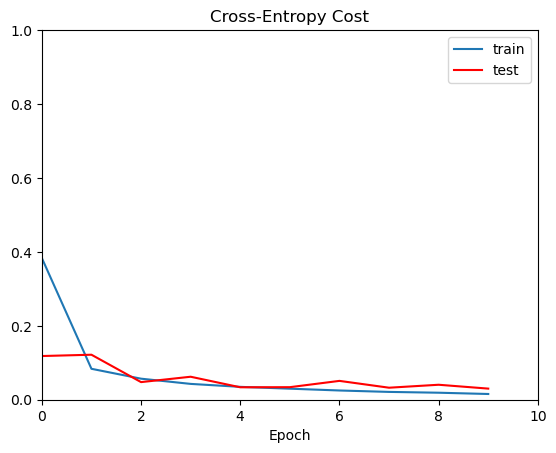

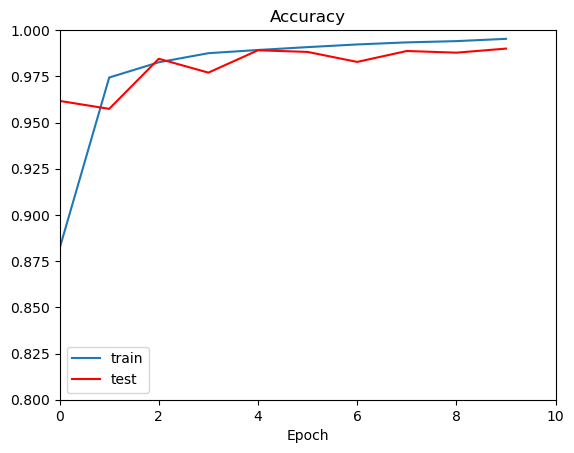

In [9]:
plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test)

#### Hyper-Parameter Tuning

Modify learning rate, batchsize, number of layers and units per layer and explore what changes these modification have on performance (train and test accuracy).

...

#### GPU

In [29]:
device = None
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else: 
    device = torch.device("cpu")

print(device)

mps


In [30]:
nbatch = 64
nepochs = 10
learning_rate = 0.03

cost_hist = []
cost_hist_test = []
acc_hist = []
acc_hist_test = []

model = CNN2Layer2MLPLayer(nhidden=50, noutput=10).to(device)
cost_ce = torch.nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10000, shuffle=True)
size = len(training_loader.dataset)
nbatches = len(training_loader)

Xtest, Ytest = next(iter(test_loader))
Xtest, Ytest = Xtest.to(device), Ytest.to(device)

for epoch in range(nepochs):
    cost, acc = 0.0, 0.0
    for batch, (X, Y) in enumerate(training_loader):
        X, Y = X.to(device), Y.to(device)
        pred = model(X)
        loss = cost_ce(pred, Y)
        cost += loss.item()
        acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

        # gradient, parameter update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    cost /= nbatches
    acc /= size
    
    with torch.no_grad():
        pred = model(Xtest)
        cost_test = cost_ce(pred, Ytest).item()
        acc_test = (pred.argmax(dim=1) == Ytest).type(torch.float).mean().item()
    print("Epoch %i: %f, %f, %f, %f"%(epoch, cost, acc, cost_test, acc_test))
    cost_hist.append(cost)
    cost_hist_test.append(cost_test)
    acc_hist.append(acc)
    acc_hist_test.append(acc_test)


Epoch 0: 0.482845, 0.846733, 0.200359, 0.934100
Epoch 1: 0.135986, 0.958783, 0.084309, 0.974400
Epoch 2: 0.081178, 0.974900, 0.092009, 0.970200
Epoch 3: 0.061756, 0.981533, 0.055036, 0.981800
Epoch 4: 0.050457, 0.984017, 0.063028, 0.979800
Epoch 5: 0.043327, 0.986783, 0.040872, 0.986200
Epoch 6: 0.036818, 0.988550, 0.048812, 0.982600
Epoch 7: 0.032092, 0.990117, 0.036580, 0.988000
Epoch 8: 0.028432, 0.991517, 0.038081, 0.987400
Epoch 9: 0.025618, 0.991917, 0.041195, 0.986200


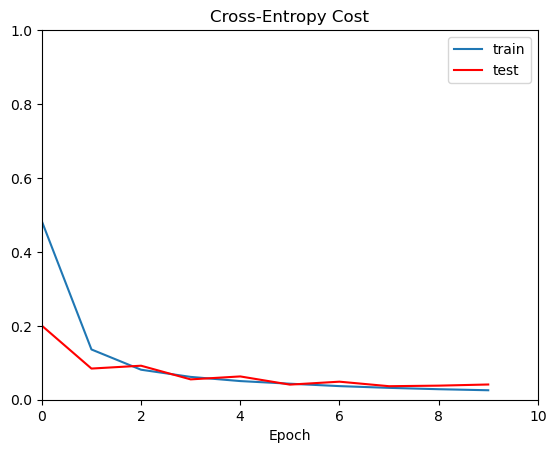

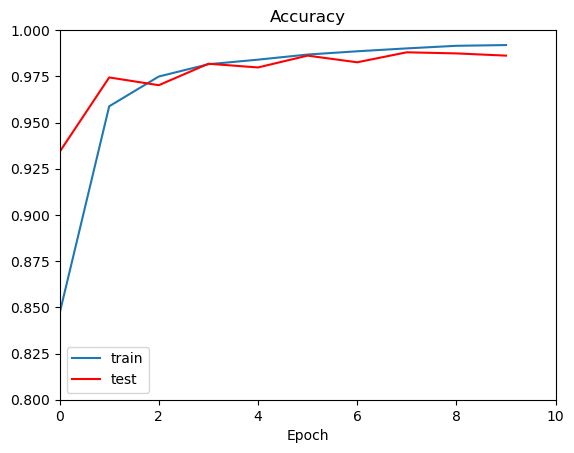

In [31]:
plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test)